<p style="text-align:right;">Mario Stanke, University of Greifswald, Germany</p>

# Solutions to Exercise Set 1 - 1-  SGD Parameters

Play with the parameters of the stochastic gradient descent algorithm.
 1. Execute the notebook with the high-level method from this morning's lecture as is (Run All).
 2. Jump to **Exercise** after the heading "Solution 2" and do as told there.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import time

In [2]:
# load the training data from the table file to a pandas data frame
df = pd.read_csv("../../bikes-summerdays.tbl", sep=r'\s+')

# convert count data to floats as regression target
df['count'] = df['count'].astype(float) 

m, n_cols = df.shape # training set size and number of columns 
print("m = ", m, "\tn_cols = ", n_cols)

# compute average of hourly bike rental counts
meancount = np.mean(df['count'])

m =  1482 	n_cols =  2


## Create Data Matrix $X$ and response vector $y$

In [3]:
# extract response vector
y_train = np.array(df['count']) 

# extract feature columns
n = n_cols - 1 # number of features
temps = np.array(df.loc[:, df.columns != 'count']) # matrix of all other columns (here only one col)

# make data matrix X
X_train = np.ones((m, n+1)) # initialize with all ones
# overwrite all but the zero-th column with features
X_train[:,1:n+1] = temps / 10 - 2.5 # normalize temperatures so they are roughly in [-1,1]

## Define Loss Function

In [4]:
# mean squared error loss function
def MSE(theta):
    # ensure X_train and y_train are torch tensors
    import torch
    if not isinstance(X_train, torch.Tensor):
        X = torch.tensor(X_train, dtype=torch.float64)
    else:
        X = X_train
    if not isinstance(y_train, torch.Tensor):
        y = torch.tensor(y_train, dtype=torch.float64)
    else:
        y = y_train
    if theta.ndim == 1:
        theta = theta.reshape(-1, 1)
    if not isinstance(theta, torch.Tensor):
        theta = torch.tensor(theta, dtype=torch.float64)
    yhat = torch.matmul(X, theta)
    d = (yhat - y.view(-1, 1))**2
    E = torch.sum(d, dim=0) / m
    return E

In [5]:
# two tests of calls to error function
print("single point:", MSE(np.array([1., 2.])))
print("two points: ", MSE(np.array([[1., 3.], [2., 4.]])))

single point: tensor([126566.3068], dtype=torch.float64)
two points:  tensor([126566.3068, 125266.2414], dtype=torch.float64)


In [6]:
# this is for lecture purposes only and NEED NOT BE READ
def contourPlot():
    ''' Plot the error landscape'''
    # compute error for the grid of all combinations of theta0 and theta1 values
    theta0 = theta1 = np.arange(-3200., 3200., 100) # grid axis ranges
    xv, yv = np.meshgrid(theta0, theta1) # x and y values of all grid points
    Theta = np.array([xv, yv]).reshape(2, -1) # 2 rows, one col per grid point

    # compute error for all grid points
    z = MSE(Theta).numpy()
    print (z.shape)
    z = z.reshape((theta0.size, -1)) # make this a matrix again as required by contour

    ## make contour plot
    _, axC = plt.subplots()
    # heights to draw contour lines for
    h = [50000, 200000] + list(range(500000, 6000001, 500000))
    contours = axC.contour(theta0, theta1, z, levels=h, colors='black')
    axC.clabel(contours, inline=True, fontsize=8, fmt='%i') # labels on lines
    plt.title("mean squared error " + r'$E(\theta)$');
    plt.xlabel(r'$\theta_0$')
    plt.ylabel(r'$\theta_1$');
    return axC


## Visualization of optimization progress

In [7]:
def plot_error(err, col):
    ''' Plot error over time'''
    plt.subplots()
    plt.plot(np.log(err), 'o-', color=col, linewidth=.2, markersize=3, mfc='none')
    plt.title("Log error by iteration of gradient descent")
    plt.xlabel('iteration '+r'$i$')
    plt.ylabel(r'$ln \;E(\theta^{(i)})$');

def plot_progress(Theta, err, col, ):
    '''Plot error and parameters over time'''
    plot_error(err, col)
    # enter parameter trajectory to above contour plot
    axC = contourPlot()
    plt.plot(Theta[0, 0], Theta[1, 0], 'o', color='green', mfc='none') # mark starting point with circle
    ymin, ymax = axC.get_ylim()
    xmin, xmax = axC.get_xlim()
    for i in range(1, Theta.shape[1]):
        if (np.abs(Theta[0, i] - Theta[0, i-1]) + np.abs(Theta[1, i] - Theta[1, i-1]) > 1e-6):
            # above condition avoids arrows with a length of 0 pixels
            plt.arrow(Theta[0, i-1], Theta[1, i-1], Theta[0, i] - Theta[0, i-1], Theta[1, i] - Theta[1, i-1],
                      color=col, width=3, head_length=20, head_width=50, overhang=.9, length_includes_head=True)

## Solution 2: high-level approach

**Exercise:**  
  1. Play with the *learning rate* $\alpha$. Find a *small* value and a *large* value so that **convergence is not reached**.
  2. Play with the *momentum* $\mu$. Find a *small* value and a *large* value so that **convergence is not reached**.
  3. Play with ```batch_size```. Find a *small* value so training is significantly **slower** and a *large* value so **convergence is not reached**.
  
When you vary one parameter, leave the other parameters as they were originally.

#### Classic Option 1: Use the **keyboard**
to edit the values in below cell, then **Run -> Run Selected Cell and Below**

In [16]:
# CHANGE THIS CODE HERE for Option 1. If you choose Option 2, leave these values as defaults (0.01, 0.8 and 32, respectively)
alpha = 0.01    # Solution: 0.001 and 1.6
mu = 0.8        # Solution: 0.0 and 0.99
batch_size = 32 # Solution: 2 and 200

#### Comfortable Option 2: Use the **mouse**
Execute the next two cells, use the sliders to adjust the values, then run the rest of the cells.  
*Tip:* **Create New View for Output** by right-clicking on the blue bar left of the graphs. Then drag the output window to a comfy place.

In [ ]:
import ipywidgets as widgets
style = {'description_width': 'initial'}
layout = widgets.Layout(width = '100%')
alpha_slider = widgets.FloatLogSlider(value = alpha, min = -4, max = 1, step = 0.001,
    description = 'learning rate alpha', readout_format = '.4f',
    style = style, layout = layout)
mu_slider = widgets.FloatSlider(value = mu, min = 0, max = 1.0, step = 0.01,
    description = 'momentum mu', readout_format = '.2f',
    style = style, layout = layout)
batch_slider = widgets.IntSlider(value = batch_size, min = 1, max = m, step = 1,
                                 description = 'batch size:', style = style, layout = layout)

In [10]:
display(alpha_slider)
display(mu_slider)
display(batch_slider)

FloatLogSlider(value=0.01, description='learning rate alpha', layout=Layout(width='100%'), max=1.0, min=-4.0, …

FloatSlider(value=0.8, description='momentum mu', layout=Layout(width='100%'), max=1.0, step=0.02, style=Slide…

IntSlider(value=32, description='batch size:', layout=Layout(width='100%'), max=1482, min=1, style=SliderStyle…

In [11]:
alpha = alpha_slider.value
mu = mu_slider.value
batch_size = batch_slider.value

In [12]:
print ("Used values alpha =", alpha, ", mu =", mu, ", batch_size =", batch_size)

Used values alpha = 0.01 , mu = 0.8 , batch_size = 32


In [13]:
X_train_t = torch.tensor(X_train, dtype=torch.float64)
y_train_t = torch.tensor(y_train, dtype=torch.float64)
dataset = TensorDataset(X_train_t, y_train_t)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
theta_init = np.array([2000., 3000.])
model = nn.Linear(2, 1, bias=False).double()
model.weight.data = torch.tensor(theta_init.reshape(1, -1))
loss_object = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=alpha, momentum=mu)
Theta = [theta_init.copy()]
loss_history = []    # new: losses per epoch
start = time.time()
epochs = 10
for epoch in range(epochs):
    epoch_loss = 0.0
    for xb, yb in loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_object(pred.view(-1), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    loss_history.append(epoch_loss)    # record loss for each epoch
    Theta.append(model.weight.detach().numpy().flatten())
    print(f"Epoch {epoch+1} loss: {epoch_loss}")
end = time.time()
print("Training took", end - start, "seconds.")

Epoch 1 loss: 64834577.943827905
Epoch 2 loss: 4547514.208018482
Epoch 3 loss: 1500063.9610226979
Epoch 4 loss: 1286809.1274023028
Epoch 5 loss: 1288434.6768452812
Epoch 6 loss: 1270229.441309303
Epoch 7 loss: 1335468.4221138416
Epoch 8 loss: 1279376.8739435058
Epoch 9 loss: 1274409.1514309398
Epoch 10 loss: 1272594.0045893544
Training took 0.21162199974060059 seconds.


(4096,)


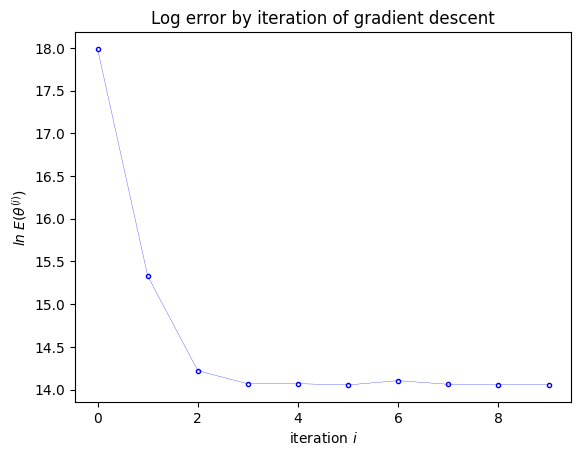

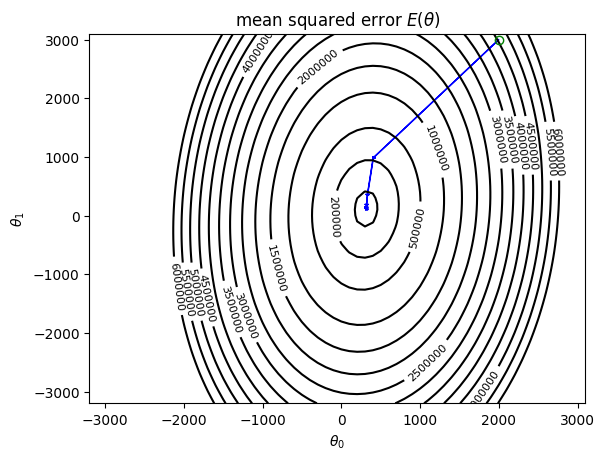

In [14]:
plot_progress(np.stack(Theta,-1), loss_history, col='blue');    

**Remarks:**
  - In above plot of training error, the errors were measured only on a batch and are thus estimates of the training error only.
  - When using stochastic gradient descent, typically the parameter trajectory eventually random walks near a local optimum and their latest values may result in a larger loss than some parameter value previously attained.

In [15]:
# final loss and prediction computed on all training data
pred = model(X_train_t).view(-1)
E = loss_object(pred, y_train_t)
print("final error = ", E.item())
print("theta:\n", model.weight.detach().numpy())

final error =  27226.994260547388
theta:
 [[317.06334084 114.00217979]]
